# Setup and Imports


In [108]:
# Run this cell first in every notebook
import os
import sys

sys.path.append(os.path.abspath('../src'))

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

from demodulator import (
    downconvert_to_baseband,
    estimate_baseband_bandwidth,
    load_mono_normalized_audio,
    locate_pilot_start,
    matched_filter_sync,
    slice_pilot_samples,
    downsample_from_offset
)
from modulator import map_bits_to_symbols
from plot_utils import plot_complex_parts, plot_correlation_response, plot_fft
from sync import generate_zadoff_chu_audio
import config


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# System Parameters


In [109]:
# Match these exactly to TX.
FS = config.FS
F_CARRIER = config.F_CARRIER
SYMBOL_RATE = config.SYMBOL_RATE
SAMPLES_PER_SYMBOL = config.SAMPLES_PER_SYMBOL
ZC_ROOT = config.u_zadoff_chu
ZC_LENGTH = config.len_zadoff_chu
SYNC_GAP_SECONDS = config.SYNC_GAP_SECONDS

rx_path = '../data/tx_single_carrier_test.wav'

""" rx_path = '../data/tx_single_carrier_test.wav' """

" rx_path = '../data/tx_single_carrier_test.wav' "

# Load and Downconvert Audio


In [110]:
fs, rx_audio = load_mono_normalized_audio(rx_path)
if fs != FS:
    raise ValueError(f'Expected sample rate {FS}, got {fs}')

estimated_bw = estimate_baseband_bandwidth(
    SYMBOL_RATE,
    pulse_method=config.pulse_method,
    margin=1.05,
)

rx_baseband = downconvert_to_baseband(
    rx_audio=rx_audio,
    fs=FS,
    carrier_freq=F_CARRIER,
    cutoff_hz=estimated_bw,
    filter_order=5,
)

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'FFT'}, xlabel='Frequency [Hz]', ylabel='Magnitude'>)

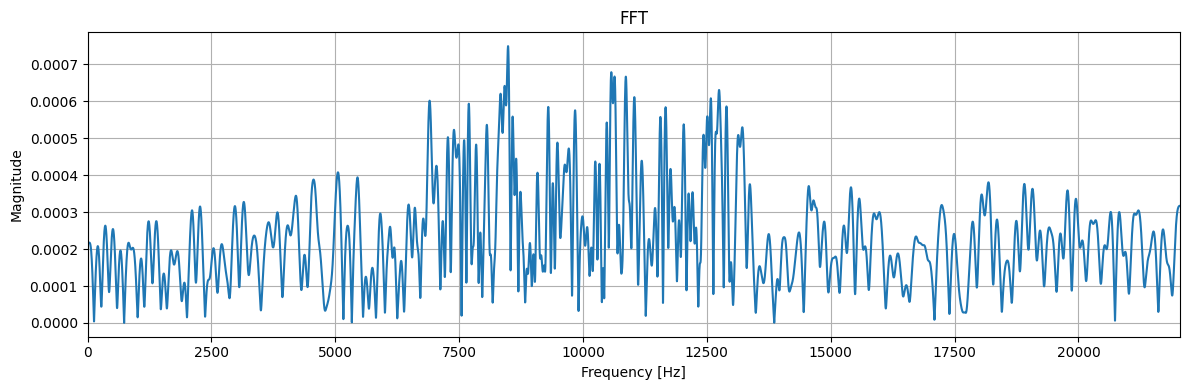

In [111]:
plot_fft(rx_audio,FS)

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'FFT'}, xlabel='Frequency [Hz]', ylabel='Magnitude'>)

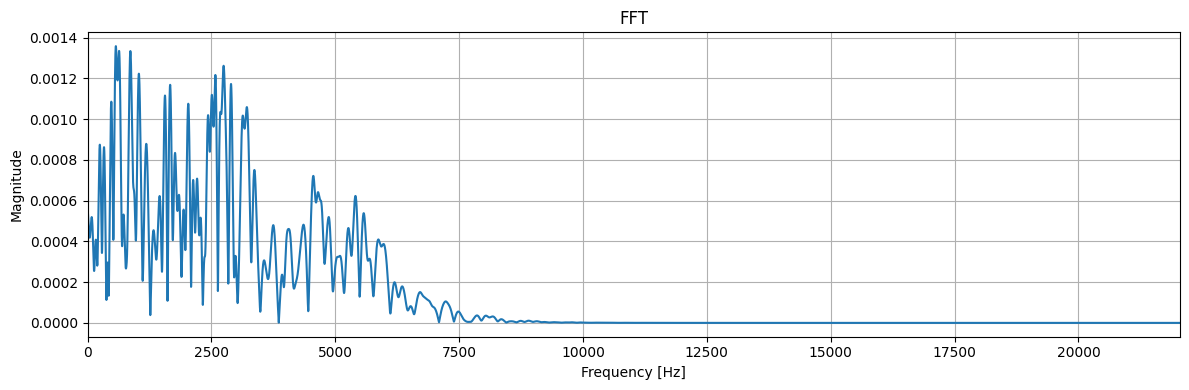

In [112]:
plot_fft(rx_baseband,FS)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Real Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>,
        <Axes: title={'center': 'Imaginary Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>],
       dtype=object))

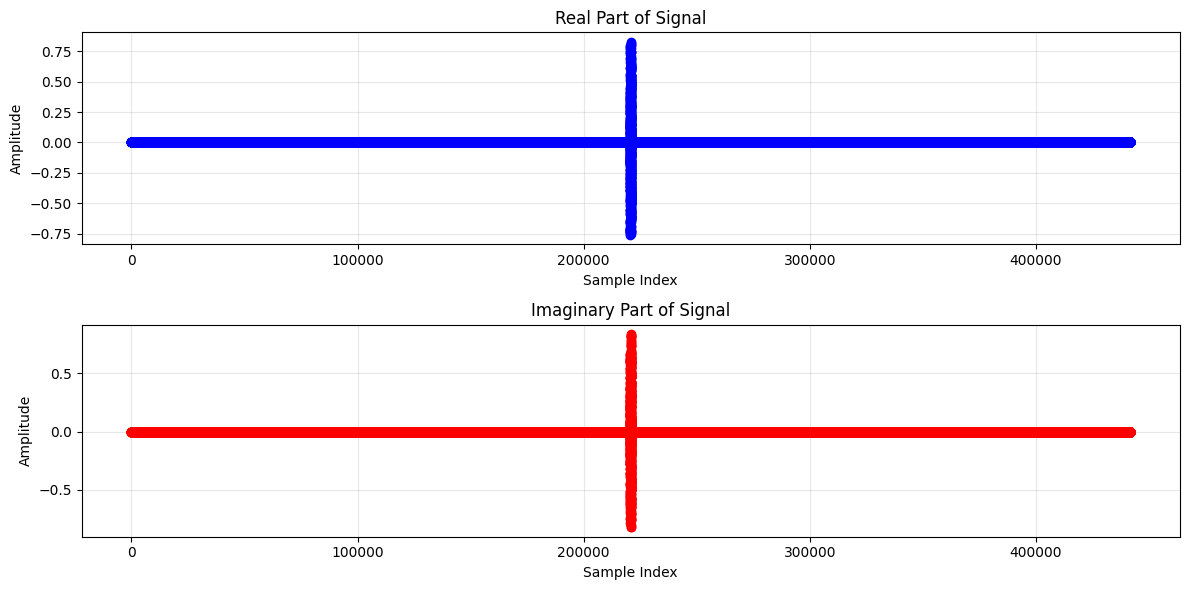

In [113]:
plot_complex_parts(rx_baseband)

In [114]:
reference_zc = generate_zadoff_chu_audio(ZC_LENGTH, ZC_ROOT)
zc_start_idx, corr = matched_filter_sync(rx_baseband, reference_zc)

pilot_start_idx = locate_pilot_start(
    sync_start_idx=zc_start_idx,
    sync_length=ZC_LENGTH,
    fs=FS,
    gap_seconds=SYNC_GAP_SECONDS,
)

print('-' * 50)
print(f'Zadoff-Chu peak found at sample index: {zc_start_idx}')
print(f'Known pilots begin at sample index: {pilot_start_idx}')
print('-' * 50)


--------------------------------------------------
Zadoff-Chu peak found at sample index: 220500
Known pilots begin at sample index: 220853
--------------------------------------------------


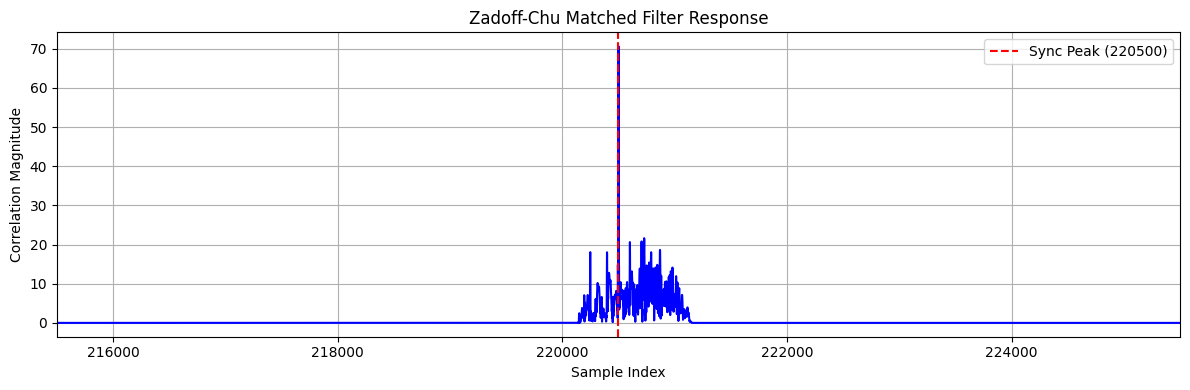

In [115]:
plot_correlation_response(corr, zc_start_idx)
plt.show()


# Pilot Extraction


In [116]:
pilot_bits = [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0]
pilot_symbols = map_bits_to_symbols(pilot_bits, config.M, METHOD=config.modulation_method)
KNOWN_PILOT_SYMBOLS = pilot_symbols

rx_pilots = slice_pilot_samples(
    rx_baseband=rx_baseband,
    pilot_start_idx=pilot_start_idx,
    num_pilot_symbols=len(KNOWN_PILOT_SYMBOLS),
    samples_per_symbol=SAMPLES_PER_SYMBOL,
)


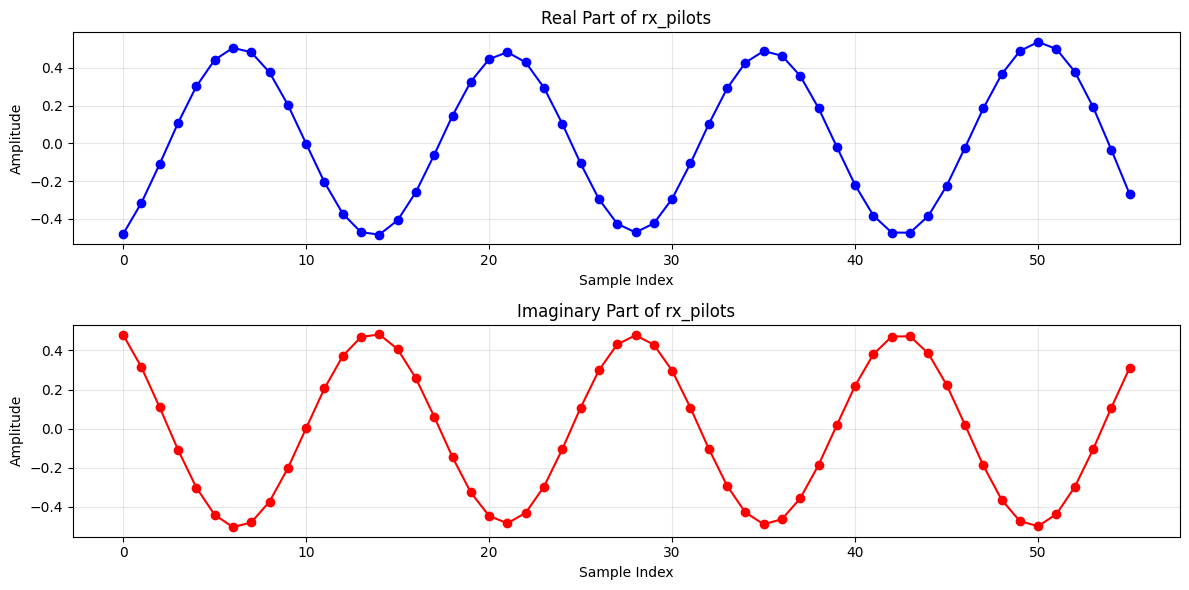

In [117]:
plot_complex_parts(rx_pilots[config.SPAN*SAMPLES_PER_SYMBOL:], title_prefix='rx_pilots')
plt.show()

### Synchronization 

Best offset inside pilot slice: 0


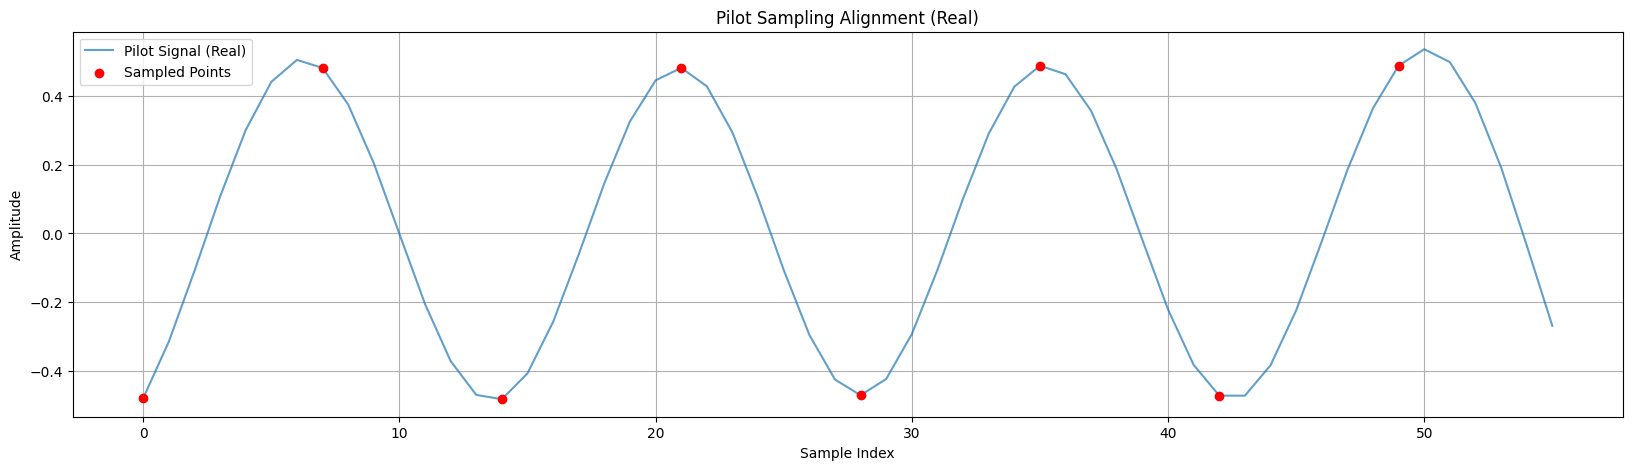

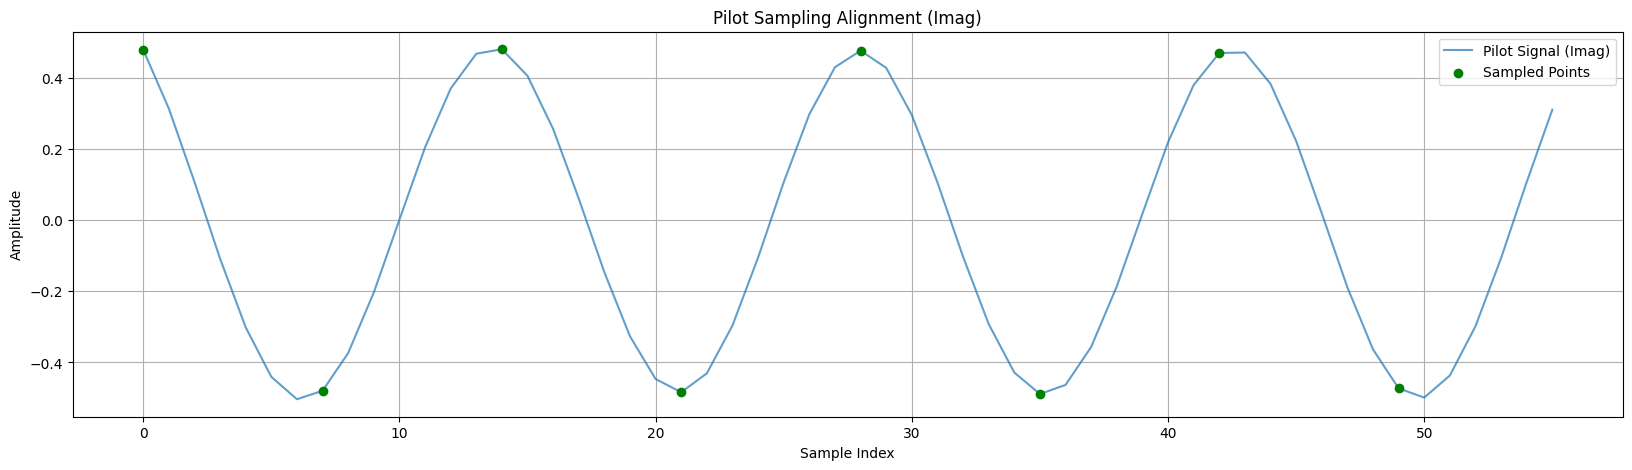


Known pilot symbols:
[-0.70710678+0.70710678j  0.70710678-0.70710678j -0.70710678+0.70710678j
  0.70710678-0.70710678j -0.70710678+0.70710678j  0.70710678-0.70710678j
 -0.70710678+0.70710678j  0.70710678-0.70710678j]

Recovered pilot samples:
[-0.48036476+0.47984995j  0.48267554-0.47985501j -0.48341207+0.48156744j
  0.48290365-0.48399923j -0.4718217 +0.47753767j  0.4890592 -0.4889184j
 -0.4728491 +0.47088279j  0.48926686-0.47309661j]


In [118]:
L = SAMPLES_PER_SYMBOL
KNOWN = KNOWN_PILOT_SYMBOLS

# ================================
# REMOVE SINC DELAY REGION
# ================================
rxp = rx_pilots[config.SPAN * L:]

NUM_PILOTS = len(KNOWN)

# ================================
# FIND BEST OFFSET
# ================================
best_offset = 0
best_metric = -np.inf

for offset in range(L):
    samples = rxp[offset::L][:NUM_PILOTS]
    
    metric = np.abs(np.sum(samples * np.conj(KNOWN)))
    
    if metric > best_metric:
        best_metric = metric
        best_offset = offset

print(f"Best offset inside pilot slice: {best_offset}")

# ================================
# GET FINAL SAMPLE INDICES
# ================================
sample_indices = np.arange(best_offset, best_offset + NUM_PILOTS*L, L)

# ================================
# PLOT REAL PART
# ================================
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

plt.plot(np.real(rxp), label="Pilot Signal (Real)", alpha=0.7)

plt.scatter(sample_indices,
            np.real(rxp[sample_indices]),
            color='red',
            label="Sampled Points",
            zorder=5)

plt.title("Pilot Sampling Alignment (Real)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

# ================================
# PLOT IMAG PART
# ================================
plt.figure(figsize=(20,5))

plt.plot(np.imag(rxp), label="Pilot Signal (Imag)", alpha=0.7)

plt.scatter(sample_indices,
            np.imag(rxp[sample_indices]),
            color='green',
            label="Sampled Points",
            zorder=5)

plt.title("Pilot Sampling Alignment (Imag)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

# ================================
# VERIFY SYMBOLS
# ================================
rx_samples = rxp[best_offset::L][:NUM_PILOTS]

print("\nKnown pilot symbols:")
print(KNOWN)

print("\nRecovered pilot samples:")
print(rx_samples)

In [119]:
start = pilot_start_idx + config.SPAN * L + best_offset

downsampled_symbols, ds_signal = downsample_from_offset(
    rx_baseband,
    start,
    L
)

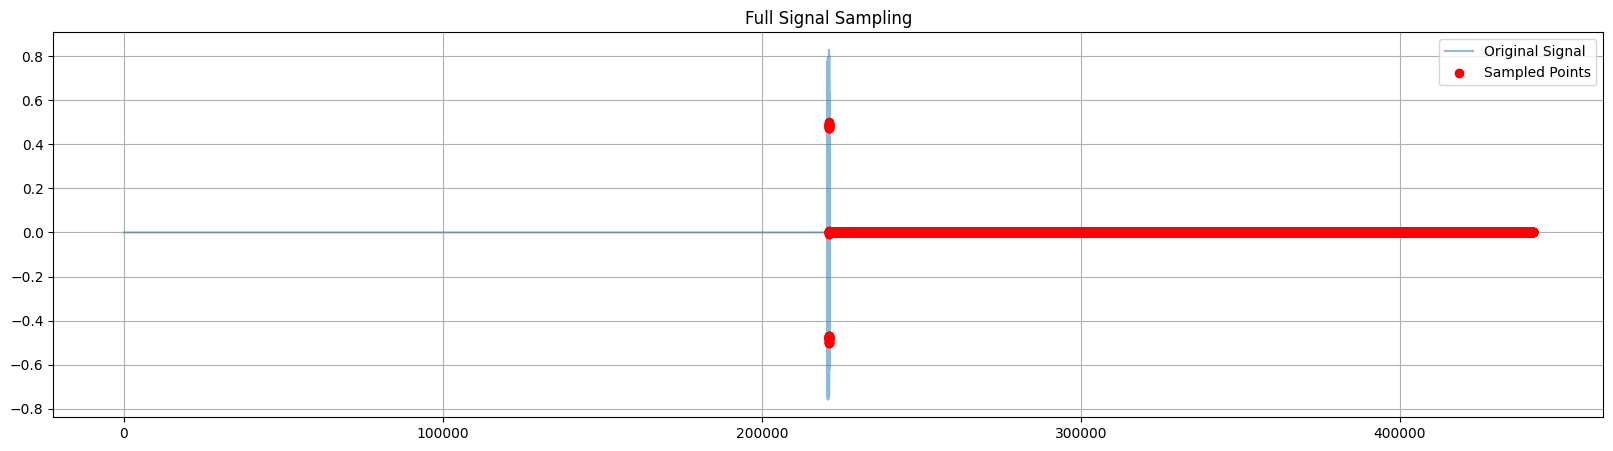

In [120]:
plt.figure(figsize=(20,5))

plt.plot(np.real(rx_baseband), label="Original Signal", alpha=0.5)

sample_indices = np.arange(start, len(rx_baseband), L)

plt.scatter(sample_indices,
            np.real(rx_baseband[sample_indices]),
            color='red',
            label="Sampled Points",
            zorder=5)

plt.title("Full Signal Sampling")
plt.grid(True)
plt.legend()
plt.show()

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Real Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>,
        <Axes: title={'center': 'Imaginary Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>],
       dtype=object))

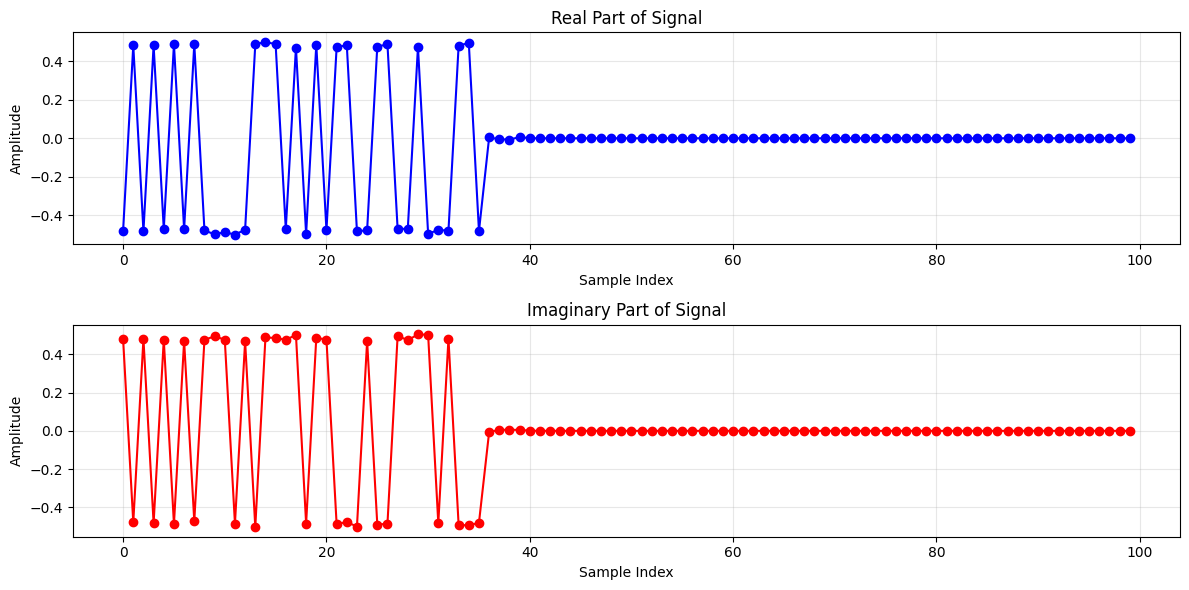

In [121]:
plot_complex_parts(rx_baseband[sample_indices][0:100])

In [122]:
data_text="Toshith"
data_binary=''.join(format(ord(c), '08b') for c in data_text)
print(data_binary)

01010100011011110111001101101000011010010111010001101000
